In [1]:
import json
import matplotlib.pyplot as plt

In [3]:
# Load in metrics from teh JSON files
with open("results/baseline_metrics.json", "r") as f:
    baseline_results = json.load(f)
with open("results/he_metrics.json", "r") as f:
    he_results = json.load(f)
with open("results/dp_metric.json", "r") as f:
    dp_results = json.load(f)
with open("results/hybrid_metrics.json", "r") as f:
    hybrid_results = json.load(f)

results_dict = {"Baseline": baseline_results, "Only HE": he_results, 
                "Only DP": dp_results, "Hybrid": hybrid_results}

## Accuracy Analysis

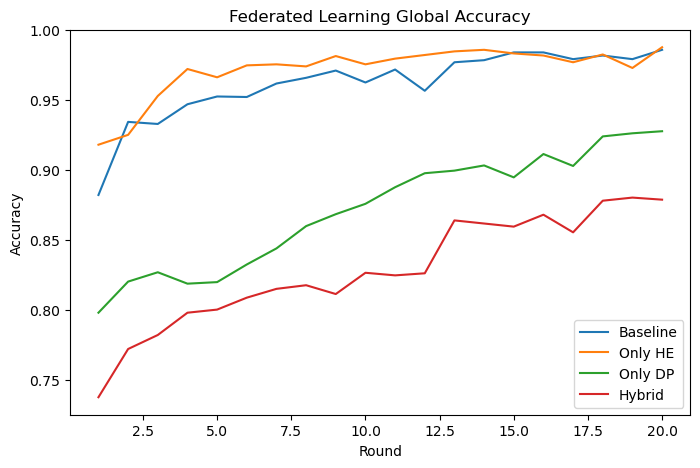

In [6]:
# Rounds Vs Accuracy
plt.figure(figsize=(8, 5))
for framework, result in results_dict.items():
    accuracy_data = result["metrics_distributed"]["accuracy"]
    rounds = [item[0] for item in accuracy_data]
    accuracies = [item[1] for item in accuracy_data]
    plt.plot(rounds, accuracies, label = framework)
plt.title("Federated Learning Global Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

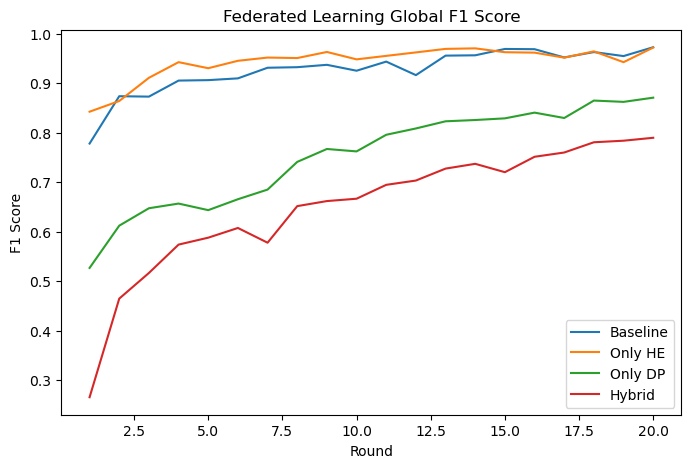

In [8]:
# Rounds Vs F1 Score
plt.figure(figsize=(8, 5))
for framework, result in results_dict.items():
    accuracy_data = result["metrics_distributed"]["f1_score"]
    rounds = [item[0] for item in accuracy_data]
    accuracies = [item[1] for item in accuracy_data]
    plt.plot(rounds, accuracies, label = framework)
plt.title("Federated Learning Global F1 Score")
plt.xlabel("Round")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

## Computational Cost Analysis

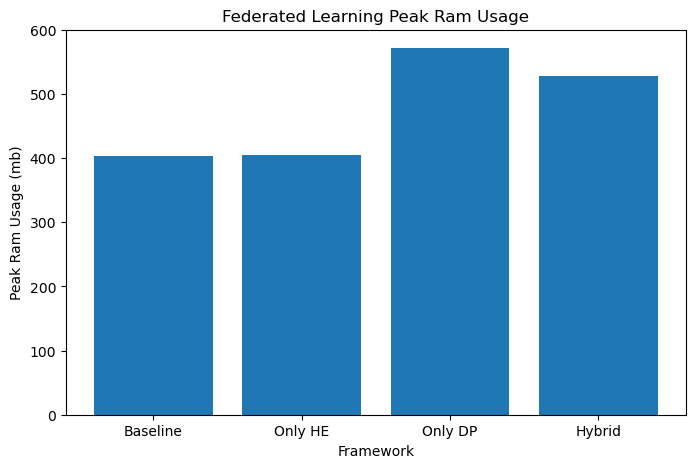

In [10]:
# Framework Vs Ram Usage
plt.figure(figsize=(8, 5))
peak_ram_list = []
framework_list = []
for framework, result in results_dict.items():
    ram_data = result["metrics_distributed"]["avg_ram_mb"]
    rounds = [item[0] for item in ram_data]
    peak_ram = max([item[1] for item in ram_data])
    
    peak_ram_list.append(peak_ram)
    framework_list.append(framework)
plt.bar(framework_list, peak_ram_list)
plt.title("Federated Learning Peak Ram Usage")
plt.xlabel("Framework")
plt.ylabel("Peak Ram Usage (mb)")
plt.show()

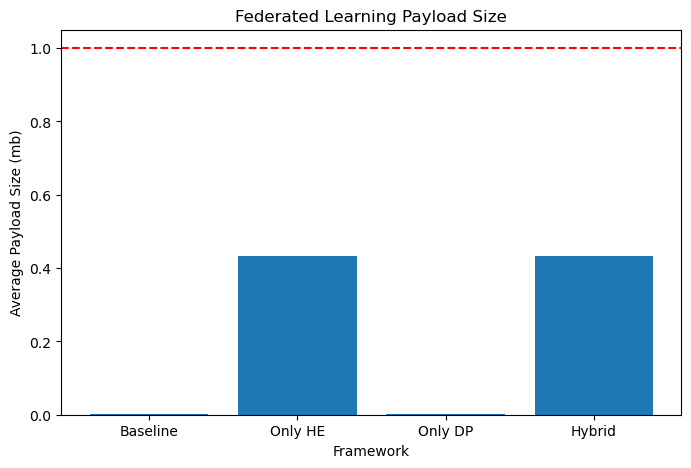

In [14]:
# Framework Vs Payload Size
# Framework Vs Ram Usage
plt.figure(figsize=(8, 5))
peak_payload_list = []
framework_list = []
for framework, result in results_dict.items():
    payload_data = result["metrics_distributed"]["avg_payload_mb"]
    rounds = [item[0] for item in payload_data]
    peak_payload = max([item[1] for item in payload_data])
    
    peak_payload_list.append(peak_payload)
    framework_list.append(framework)
plt.bar(framework_list, peak_payload_list)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Federated Learning Payload Size")
plt.xlabel("Framework")
plt.ylabel("Average Payload Size (mb)")
plt.show()